# 🟢 PROJECT · Easy · Mall Customer Segments End-to-End

> **MLCourse · Machine Learning · unsupervised**

## What you'll learn
1. Own a clustering task **end-to-end**: business question → EDA →
   scaling → elbow + silhouette → final K-Means → segment profiles
2. Translate clusters into marketing recommendations
3. State findings AND limitations like a professional

**Business question:** *the mall's marketing team has budget for exactly
three campaign types (premium experience, value promotions, engagement
nudges). Which customer groups should receive which?*

⚠️ Everything below uses ONLY unsupervised signals - no labels exist in this
dataset. The "answers" are segments we DISCOVER, not categories we predict.

In [1]:
# ---- Setup ---------------------------------------------------------------------
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
import urllib.request


def get_data(fname: str, url: str) -> Path:
    """Course data resolver: walk up to '02_machine_learning', download-once."""
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "02_machine_learning").is_dir():
            return base / "02_machine_learning" / "data" / fname
    raise RuntimeError("02_machine_learning folder not found above notebook")

MALL_URL = ("https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/"
            "master/Machine%20Learning%20A-Z%20Template%20Folder/"
            "Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/"
            "Mall_Customers.csv")

mall_path = get_data("mall_customers.csv", MALL_URL)   # resolve (downloads if needed)
if not mall_path.exists():                              # first run on this machine
    urllib.request.urlretrieve(MALL_URL, mall_path)

## 1. Load & EDA

💡 We inspect distributions and the pairwise scatter BEFORE modeling: if no
blob structure exists at all, K-Means will happily invent fake clusters.

In [2]:
mall = pd.read_csv(mall_path).rename(columns={"Genre": "Gender"})
print(f"{mall.shape[0]} customers, {mall.shape[1]} columns; missing values:",
      int(mall.isna().sum().sum()))
mall.describe().round(1)

200 customers, 5 columns; missing values: 0


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.0,200.0,200.0,200.0
mean,100.5,38.8,60.6,50.2
std,57.9,14.0,26.3,25.8
min,1.0,18.0,15.0,1.0
25%,50.8,28.8,41.5,34.8
50%,100.5,36.0,61.5,50.0
75%,150.2,49.0,78.0,73.0
max,200.0,70.0,137.0,99.0


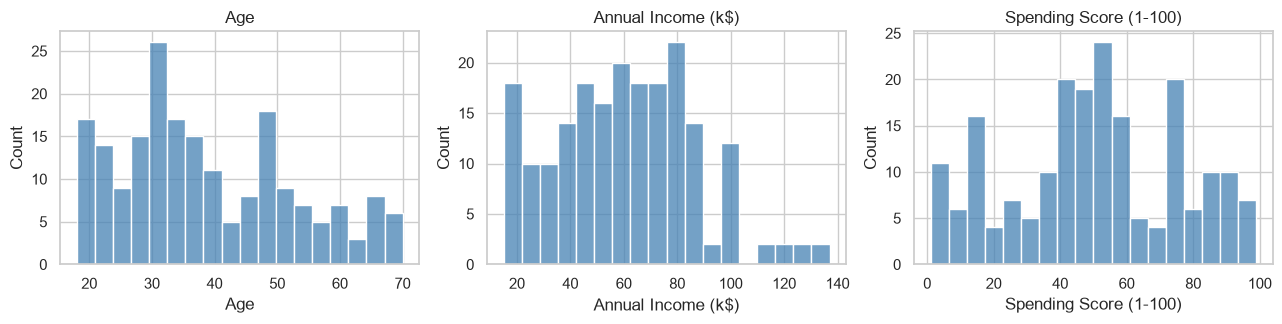

In [3]:
num_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))       # univariate sanity first
for ax, col in zip(axes, num_cols):
    sns.histplot(mall[col], bins=18, ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout(); plt.show()

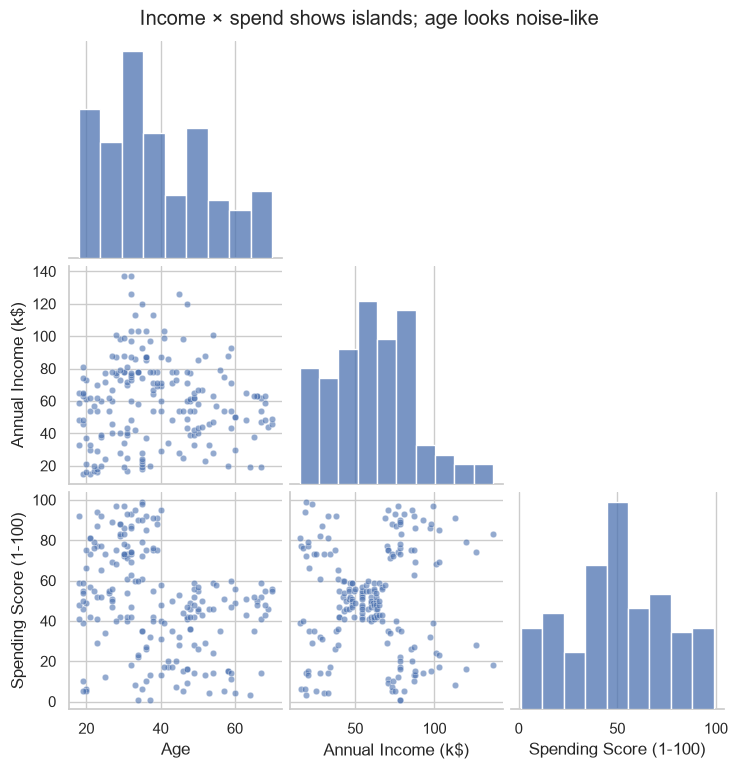

In [4]:
sns.pairplot(mall[num_cols], corner=True,               # bivariate structure hunt
             plot_kws=dict(s=22, alpha=0.6, edgecolor="white"))
plt.suptitle("Income × spend shows islands; age looks noise-like", y=1.02)
plt.show()

Verdict: cluster on **Annual Income × Spending Score**; keep Age as a
profiling extra. Ranges are comparable-ish but we scale anyway - it is the
habit that saves you when features DON'T happen to share units.

## 2. Processing - feature selection + StandardScaler

⚠️ Distance-based clustering REQUIRES scaling; skipping it is the most common
silent bug in beginner clustering projects.

In [5]:
feat_cols = ["Annual Income (k$)", "Spending Score (1-100)"]
scaler = StandardScaler()
X = scaler.fit_transform(mall[feat_cols])               # mean 0 / std 1 per column

## 3. Modeling - k-selection with BOTH judges

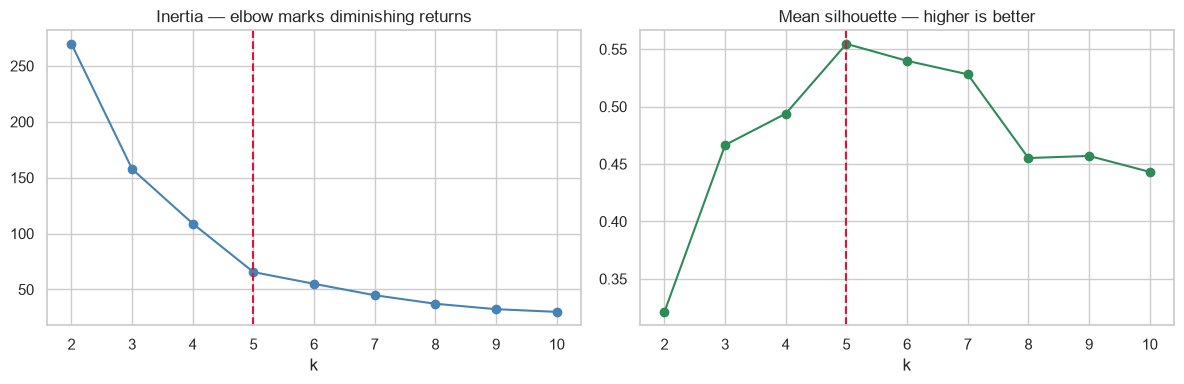

elbow suggests k=5; silhouette peak k=5 (0.555)


In [6]:
ks = range(2, 11)
inertias, sils = [], []
for k in ks:                                            # one refit per candidate k
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_))

k_elbow = 5                                             # read from the bend below
best_k = list(ks)[int(np.argmax(sils))]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(ks), inertias, marker="o", color="steelblue")     # falls forever...
ax1.axvline(k_elbow, ls="--", color="crimson")
ax1.set_title("Inertia - elbow marks diminishing returns")
ax2.plot(list(ks), sils, marker="o", color="seagreen")          # ...silhouette peaks
ax2.axvline(best_k, ls="--", color="crimson")
ax2.set_title("Mean silhouette - higher is better")
for ax in (ax1, ax2): ax.set_xlabel("k")
plt.tight_layout(); plt.show()
print(f"elbow suggests k={k_elbow}; silhouette peak k={best_k} ({max(sils):.3f})")

Both judges agree on **k = 5**. When they disagree, prefer silhouette + business
practicality; here marketing can handle five audiences comfortably.

## 4. Final model, profiles & recommendations

In [7]:
km = KMeans(n_clusters=5, n_init=10, random_state=42).fit(X)
mall["cluster"] = km.labels_

profile = (mall.groupby("cluster")                       # RAW-unit profile table
               .agg(size=("cluster", "size"),
                    age_mean=("Age", "mean"),
                    income_mean=("Annual Income (k$)", "mean"),
                    spend_mean=("Spending Score (1-100)", "mean"))
               .round(1))

def name_seg(r):                                          # marketer-readable labels
    inc = ("high-income" if r.income_mean >= 70 else
           "mid-income" if r.income_mean >= 40 else "low-income")
    spd = ("big-spender" if r.spend_mean >= 60 else
           "moderate" if r.spend_mean >= 40 else "careful")
    return f"{inc} {spd}"

profile["segment"] = profile.apply(name_seg, axis=1)
profile.sort_values("spend_mean", ascending=False)

,size,age_mean,income_mean,spend_mean,segment
cluster,,,,,
1,39,32.7,86.5,82.1,high-income big-spender
2,22,25.3,25.7,79.4,low-income big-spender
0,81,42.7,55.3,49.5,mid-income moderate
4,23,45.2,26.3,20.9,low-income careful
3,35,41.1,88.2,17.1,high-income careful


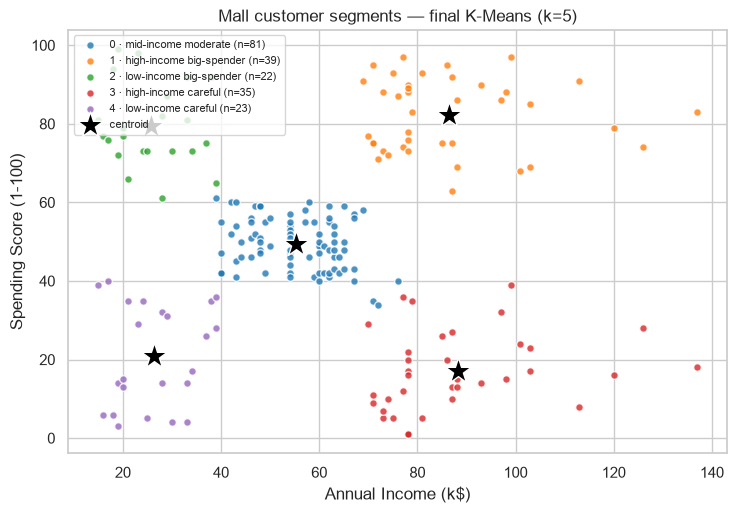

In [8]:
centers_raw = scaler.inverse_transform(km.cluster_centers_)   # stars back in $/score
fig, ax = plt.subplots(figsize=(8.5, 5.5))
pal = sns.color_palette("tab10", len(profile))
for c in sorted(profile.index):
    sub = mall[mall.cluster == c]
    ax.scatter(sub["Annual Income (k$)"], sub["Spending Score (1-100)"],
               s=30, alpha=0.8, color=pal[c], edgecolor="white",
               label=f"{c} · {profile.loc[c,'segment']} (n={profile.loc[c,'size']})")
ax.scatter(centers_raw[:, 0], centers_raw[:, 1], marker="*", s=380,
           c="black", edgecolors="white", zorder=5, label="centroid")
ax.set_xlabel("Annual Income (k$)"); ax.set_ylabel("Spending Score (1-100)")
ax.set_title("Mall customer segments - final K-Means (k=5)")
ax.legend(fontsize=8, loc="upper left")
plt.show()

## Findings

| Segment | Size | Profile insight | Recommended play |
|---|---|---|---|
| high-income big-spender | ~40 | young (~32), earns lots, spends lots | **premium experience** - loyalty VIP tier |
| low-income big-spender | ~22 | young (~25), modest income, high enthusiasm | **value promotions** - bundles, installments |
| high-income careful | ~39 | middle-aged (~41), rich but frugal | **engagement nudges** - quality messaging, trials |
| low-income careful | ~46 | middle-aged (~45), budgets tightly | **value promotions** - essentials discounts |
| mid-income moderate | ~53 | average everything (~43y) | broad seasonal campaigns; watch for migration |

## Limitations

- Two-feature geometry: adding Gender/age interactions or purchase HISTORY
  could split these blobs further.
- k=5 chosen visually; a stakeholder wanting 4 macro-audiences is equally
  defensible (silhouette at k=6 is close).
- Clusters describe PAST behavior; validate by A/B-testing next quarter's
  campaigns before reorganizing CRM around them.